<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/Dimension009.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/tmp/ipython-input-1629651113.py:19: RuntimeWarning: overflow encountered in power
  kappa_vals = beta * kappa_vals + (1 - beta) * kappa_t + gamma * sigma + epsilon * kappa_vals**3
/tmp/ipython-input-1629651113.py:18: RuntimeWarning: overflow encountered in power
  delta_vals = alpha * delta_vals + (1 - alpha) * delta_t - gamma * sigma + epsilon * delta_vals**3
/tmp/ipython-input-1629651113.py:23: RuntimeWarning: invalid value encountered in divide
  probs = sigma / np.sum(sigma) if np.sum(sigma) > 0 else np.zeros_like(sigma)


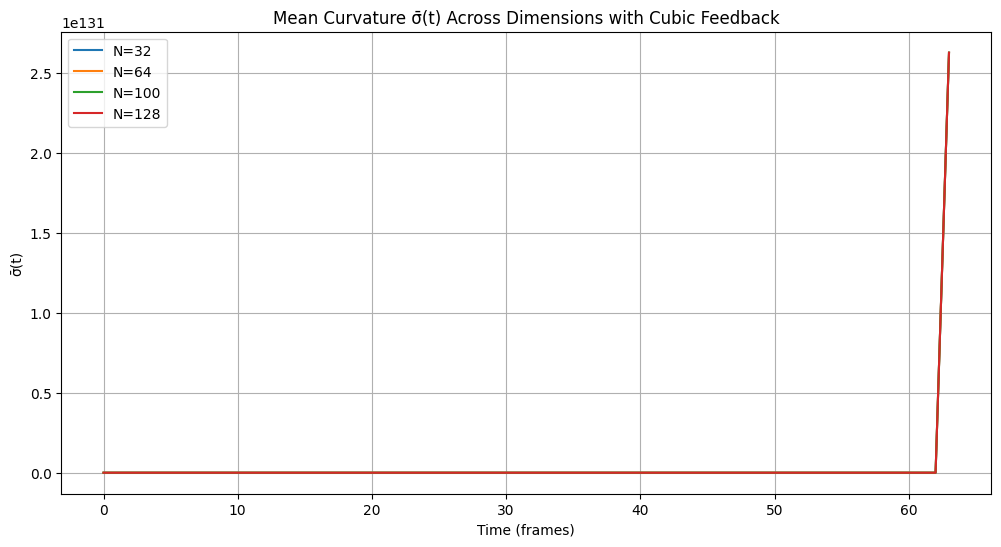

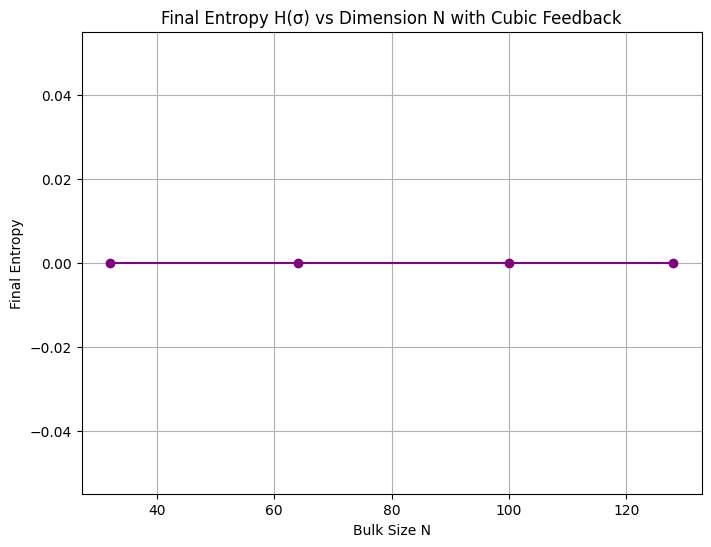

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------
# Sweep Simulation Function
# -------------------------------
def run_sweep(N, frames=100, epsilon=0.01):
    alpha, beta, gamma = 0.9, 0.9, 0.1
    delta_vals = np.zeros(N)
    kappa_vals = np.zeros(N)
    sigma_means, entropy_vals, tension_vals = [], [], []

    for t in range(frames):
        delta_t = np.sin(2 * np.pi * t / 50)
        kappa_t = np.cos(2 * np.pi * t / 50)
        sigma = np.abs(delta_vals - kappa_vals)

        delta_vals = alpha * delta_vals + (1 - alpha) * delta_t - gamma * sigma + epsilon * delta_vals**3
        kappa_vals = beta * kappa_vals + (1 - beta) * kappa_t + gamma * sigma + epsilon * kappa_vals**3

        sigma_means.append(np.mean(sigma))

        probs = sigma / np.sum(sigma) if np.sum(sigma) > 0 else np.zeros_like(sigma)
        entropy = -np.sum(probs[probs > 0] * np.log2(probs[probs > 0]))
        entropy_vals.append(entropy)

        tension = np.sum(delta_vals * kappa_vals)
        tension_vals.append(tension)

    return sigma_means, entropy_vals, tension_vals

# -------------------------------
# Run for Multiple N
# -------------------------------
Ns = [32, 64, 100, 128]
results = {N: run_sweep(N) for N in Ns}

# -------------------------------
# Plot Mean Curvature σ̄(t)
# -------------------------------
plt.figure(figsize=(12, 6))
for N in Ns:
    plt.plot(results[N][0], label=f'N={N}')
plt.title("Mean Curvature σ̄(t) Across Dimensions with Cubic Feedback")
plt.xlabel("Time (frames)")
plt.ylabel("σ̄(t)")
plt.legend()
plt.grid(True)
plt.show()

# -------------------------------
# Plot Final Entropy vs N
# -------------------------------
final_entropy = [results[N][1][-1] for N in Ns]
plt.figure(figsize=(8, 6))
plt.plot(Ns, final_entropy, marker='o', color='purple')
plt.title("Final Entropy H(σ) vs Dimension N with Cubic Feedback")
plt.xlabel("Bulk Size N")
plt.ylabel("Final Entropy")
plt.grid(True)
plt.show()
